In [1]:
import xarray as xr
import json
import pandas as pd
import torch
import numpy as np
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import os
import sys
sys.path.append('../')
import utils.evaluation as evaluation
import utils.utils as ut

In [2]:
# load true test data
settings_file_path = "../../settings.json"
with open(settings_file_path, 'r') as file:
        settings = json.load(file)
no_epochs=settings['epochs']


### Factual ###

### Load temperature TEST data ###
ds_test_eth_fact_path = os.path.join(settings['paths']['data'], settings['paths']['dataset_trefht_eth_transient']) # add 3 times climatology here
ds_test_eth_fact_pre = xr.open_dataset(ds_test_eth_fact_path)
print(ds_test_eth_fact_pre) #lat,lon,time

# load climatologies
# add path of climatologies
clim_eth_1300_pre=xr.open_dataset("other_data/TREFHT_day_b.e212.BHISTcmip6_BSSP370cmip6.f09_g17.1300_1850-2100_clim.nc")
clim_eth_1400_pre=xr.open_dataset("other_data/TREFHT_day_b.e212.BHISTcmip6_BSSP370cmip6.f09_g17.1400_1850-2100_clim.nc")
clim_eth_1500_pre=xr.open_dataset("other_data/TREFHT_day_b.e212.BHISTcmip6_BSSP370cmip6.f09_g17.1500_1850-2100_clim.nc")
clim_eth_1500_pre

# subset
eth_1300_clim = clim_eth_1300_pre.assign_coords(lon=((clim_eth_1300_pre.lon + 180) % 360) - 180).sortby("lon").sel(lat=ds_test_eth_fact_pre.lat, lon=ds_test_eth_fact_pre.lon).sel(time=slice("1980-06-02", "1980-08-31"))
eth_1400_clim = clim_eth_1400_pre.assign_coords(lon=((clim_eth_1400_pre.lon + 180) % 360) - 180).sortby("lon").sel(lat=ds_test_eth_fact_pre.lat, lon=ds_test_eth_fact_pre.lon).sel(time=slice("1980-06-02", "1980-08-31"))
eth_1500_clim = clim_eth_1500_pre.assign_coords(lon=((clim_eth_1500_pre.lon + 180) % 360) - 180).sortby("lon").sel(lat=ds_test_eth_fact_pre.lat, lon=ds_test_eth_fact_pre.lon).sel(time=slice("1980-06-02", "1980-08-31"))
eth_1300_clim #time,lat,lon

# bring climatologies into right order
combined_climatologies = np.concatenate([np.transpose(np.tile(eth_1300_clim.TREFHT.values, (251,1,1)), (1,2,0)), 
                                         np.transpose(np.tile(eth_1400_clim.TREFHT.values, (251,1,1)), (1,2,0)), 
                                         np.transpose(np.tile(eth_1500_clim.TREFHT.values, (251,1,1)), (1,2,0))], 
                                        axis=2)
print(combined_climatologies.shape)

# add climatology
ds_test_eth_fact = ds_test_eth_fact_pre.TREFHT + combined_climatologies - 273.15
ds_test_eth_fact

# load DAE ensemble
# current
dae_ensemble_fact = f"{settings['current_model']}/dae_ensemble_after_{no_epochs}_epochs/ETH_ensemble_after_{no_epochs}_epochs/ETH_gen_dpa_ens_{no_epochs}_dataset_restored.nc"
dae_eth_fact_path = os.path.join(settings['paths']['output_dir'], dae_ensemble_fact)


dae_eth_fact = xr.open_dataset(dae_eth_fact_path) + np.transpose(combined_climatologies, (2,0,1)) - 273.15
dae_eth_fact

# load nudged climatologies
# load climatologies
clim_eth_cf_1300_pre=xr.open_dataset("other_data/TREFHT_day_b.e212.B1850cmip6.f09_g17.001.nudge-1850-2100-SSP370.1300.linear-weak_shifted-1day_clim.nc")
clim_eth_cf_1400_pre=xr.open_dataset("other_data/TREFHT_day_b.e212.B1850cmip6.f09_g17.001.nudge-1850-2100-SSP370.1400.linear-weak_shifted-1day_clim.nc")
clim_eth_cf_1500_pre=xr.open_dataset("other_data/TREFHT_day_b.e212.B1850cmip6.f09_g17.001.nudge-1850-2100-SSP370.1500.linear-weak_shifted-1day_clim.nc")
clim_eth_cf_1500_pre

# subset
eth_cf_1300_clim = clim_eth_cf_1300_pre.assign_coords(lon=((clim_eth_cf_1300_pre.lon + 180) % 360) - 180).sortby("lon").sel(lat=ds_test_eth_fact_pre.lat, lon=ds_test_eth_fact_pre.lon).sel(time=slice("1980-06-02", "1980-08-31"))
eth_cf_1400_clim = clim_eth_cf_1400_pre.assign_coords(lon=((clim_eth_cf_1400_pre.lon + 180) % 360) - 180).sortby("lon").sel(lat=ds_test_eth_fact_pre.lat, lon=ds_test_eth_fact_pre.lon).sel(time=slice("1980-06-02", "1980-08-31"))
eth_cf_1500_clim = clim_eth_cf_1500_pre.assign_coords(lon=((clim_eth_cf_1500_pre.lon + 180) % 360) - 180).sortby("lon").sel(lat=ds_test_eth_fact_pre.lat, lon=ds_test_eth_fact_pre.lon).sel(time=slice("1980-06-02", "1980-08-31"))
eth_cf_1300_clim #time,lat,lon

# bring climatologies into right order
combined_climatologies_cf = np.concatenate([np.transpose(np.tile(eth_cf_1300_clim.TREFHT.values, (251,1,1)), (1,2,0)), 
                                         np.transpose(np.tile(eth_cf_1400_clim.TREFHT.values, (251,1,1)), (1,2,0)), 
                                         np.transpose(np.tile(eth_cf_1500_clim.TREFHT.values, (251,1,1)), (1,2,0))], 
                                        axis=2)

### Load counterfactual temperature TEST data ###
ds_test_eth_cf_path = os.path.join(settings['paths']['data'], settings['paths']['dataset_trefht_eth_nudged_shifted'])
ds_test_eth_cf_pre = xr.open_dataset(ds_test_eth_cf_path)
ds_test_eth_cf = ds_test_eth_cf_pre.TREFHT + combined_climatologies_cf - 273.15
ds_test_eth_cf

### Counterfactual ###
# load DAE ensemble
# load DAE ensemble
# current
dae_ensemble_cf = f"{settings['current_model']}/dae_ensemble_after_{no_epochs}_epochs/ETH_ensemble_after_{no_epochs}_epochs/ETH_cf_gen_dpa_ens_{no_epochs}_dataset_restored.nc"
dae_eth_cf_path = os.path.join(settings['paths']['output_dir'], dae_ensemble_cf)


dae_eth_cf = xr.open_dataset(dae_eth_cf_path) + np.transpose(combined_climatologies, (2,0,1)) - 273.15
dae_eth_cf

# compute domain average temperature
dae_eth_ens_spatial_mean = dae_eth_fact.TREFHT.mean(dim=("lat","lon"))
dae_eth_ens_spatial_mean_cf = dae_eth_cf.TREFHT.mean(dim=("lat","lon"))

# median
fact_dae_mean = dae_eth_fact.TREFHT.isel(time=slice(0,4769)).median(dim="ensemble_member")
cf_dae_mean = dae_eth_cf.TREFHT.isel(time=slice(0,4769)).median(dim="ensemble_member")



<xarray.Dataset> Size: 59MB
Dimensions:  (lat: 32, lon: 32, time: 14307)
Coordinates:
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * time     (time) object 114kB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00
Data variables:
    TREFHT   (lat, lon, time) float32 59MB ...
(32, 32, 14307)


In [3]:
##################
### set domain ###
##################
# FRANCE
fr_lat_min = 45
fr_lat_max = 50
fr_lon_min= 0
fr_lon_max= 5

## Bias

In [4]:
def weighted_domain_mean(da, lat_min=None, lat_max=None, lon_min=None, lon_max=None):
    """Latitude-weighted spatial mean over a rectangular domain.

    If any of lat_min, lat_max, lon_min, lon_max are None, the mean is
    computed over the entire domain along that dimension.
    """
    da_domain = da.sel(
        lat=slice(lat_min, lat_max),
        lon=slice(lon_min, lon_max),
    )
    weights = np.cos(np.deg2rad(da_domain["lat"]))
    weights = xr.DataArray(
        weights,
        coords={"lat": da_domain["lat"]},
        dims=["lat"],
    )
    return da_domain.weighted(weights).mean(dim=("lat", "lon"))

# include coordinates for using subdomain
# truth
x_eth_fact_reduced_mean = weighted_domain_mean(ds_test_eth_fact) #, fr_lat_min, fr_lat_max, fr_lon_min, fr_lon_max)
x_eth_cf_reduced_mean = weighted_domain_mean(ds_test_eth_cf) #, fr_lat_min, fr_lat_max, fr_lon_min, fr_lon_max)

# DAE
dae_eth_ens_spatial_mean = weighted_domain_mean(dae_eth_fact) #, fr_lat_min, fr_lat_max, fr_lon_min, fr_lon_max)
dae_eth_ens_spatial_mean_cf = weighted_domain_mean(dae_eth_cf) #, fr_lat_min, fr_lat_max, fr_lon_min, fr_lon_max)

In [5]:
# Truth
weights = np.cos(np.deg2rad(ds_test_eth_fact.lat))
x_eth_fact_reduced_mean_numpy = x_eth_fact_reduced_mean.values

# Counterfactual ERA5 test data
weights = np.cos(np.deg2rad(ds_test_eth_cf.lat))
x_eth_cf_reduced_mean_numpy = x_eth_cf_reduced_mean.values

######################################################
# DAE ensemble spat means

# absolute temps
dpa_eth_fact_ensemble_spat_mean = dae_eth_ens_spatial_mean #dpa_ensemble_fact_raw.TREFHT.mean(dim="lat_x_lon")
dpa_eth_cf_ensemble_spat_mean = dae_eth_ens_spatial_mean_cf #dpa_ensemble_raw_cf.TREFHT.mean(dim="lat_x_lon")

######################################################

# DAE ensemble mean spat mean
dpa_eth_fact_ensemble_mean_spat_mean = dpa_eth_fact_ensemble_spat_mean.mean(dim="ensemble_member")
dpa_eth_cf_ensemble_mean_spat_mean = dpa_eth_cf_ensemble_spat_mean.mean(dim="ensemble_member")
dpa_eth_cf_ensemble_mean_spat_mean


print("ERA5 test shapes:", x_eth_fact_reduced_mean_numpy.shape, x_eth_cf_reduced_mean_numpy.shape)
test_sets = [x_eth_fact_reduced_mean_numpy, x_eth_cf_reduced_mean_numpy]
dpa_spat_means = [dpa_eth_fact_ensemble_spat_mean, dpa_eth_cf_ensemble_spat_mean]
dae_ensemble_means_spat_means = [dpa_eth_fact_ensemble_mean_spat_mean, dpa_eth_cf_ensemble_mean_spat_mean]

ERA5 test shapes: (14307,) (14307,)


(4769,)


/tmp/ipykernel_2141940/129690528.py:5: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  time = x_eth_fact_reduced_mean.indexes["time"].to_datetimeindex()[0:4769]
/tmp/ipykernel_2141940/129690528.py:5: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  time = x_eth_fact_reduced_mean.indexes["time"].to_datetimeindex()[0:4769]


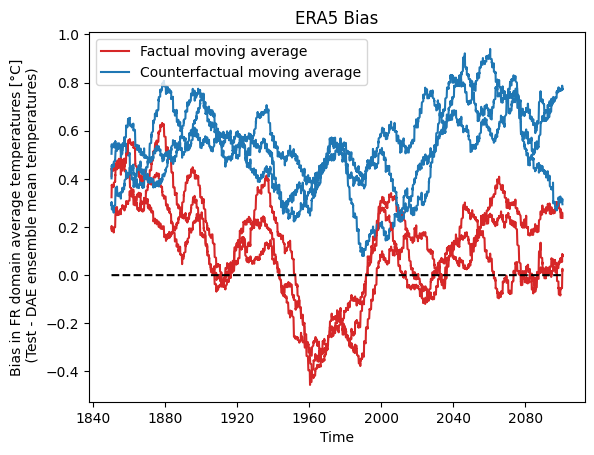

In [6]:
temporal_era5_bias_fact = x_eth_fact_reduced_mean.values - dpa_eth_fact_ensemble_mean_spat_mean.TREFHT.values
temporal_era5_bias_cf = x_eth_cf_reduced_mean - dpa_eth_cf_ensemble_mean_spat_mean.assign_coords(time=x_eth_cf_reduced_mean.time)
temporal_era5_bias_cf

time = x_eth_fact_reduced_mean.indexes["time"].to_datetimeindex()[0:4769]
print(time.shape)

#plt.scatter(time, temporal_era5_bias_fact, color="tab:red", marker='.', alpha=0.2, s=5)
#plt.scatter(time, temporal_era5_bias_cf.TREFHT.values, color="tab:blue", marker='.', alpha=0.2, s=5)
#temporal_era5_bias_fact.plot.scatter()

def moving_average_edge(x, window):
    kernel = np.ones(window)
    
    # Convolve data
    smoothed = np.convolve(x, kernel, mode='same')
    
    # Convolve ones to count how many valid points contribute at each position
    counts = np.convolve(np.ones_like(x), kernel, mode='same')
    
    return smoothed / counts

window = 200
# 1300
smooth_era5_bias_fact_1300 = moving_average_edge(temporal_era5_bias_fact[0:4769],window)
smooth_era5_bias_cf_1300 = moving_average_edge(temporal_era5_bias_cf.TREFHT.isel(time=slice(0,4769)).values, window)

# 1400
smooth_era5_bias_fact_1400 = moving_average_edge(temporal_era5_bias_fact[4769:2*4769], window)
smooth_era5_bias_cf_1400 = moving_average_edge(temporal_era5_bias_cf.TREFHT.isel(time=slice(4769,2*4769)).values, window)

# 1500
smooth_era5_bias_fact_1500 = moving_average_edge(temporal_era5_bias_fact[2*4769:3*4769], window)
smooth_era5_bias_cf_1500 = moving_average_edge(temporal_era5_bias_cf.TREFHT.isel(time=slice(2*4769,3*4769)).values, window)

plt.plot(time, smooth_era5_bias_fact_1300, color="tab:red", label="Factual moving average")
plt.plot(time, smooth_era5_bias_cf_1300, color="tab:blue", label="Counterfactual moving average")

plt.plot(time, smooth_era5_bias_fact_1400, color="tab:red")
plt.plot(time, smooth_era5_bias_cf_1400, color="tab:blue")

plt.plot(time, smooth_era5_bias_fact_1500, color="tab:red")
plt.plot(time, smooth_era5_bias_cf_1500, color="tab:blue")



plt.plot(time, np.zeros(4769), color='k', linestyle='--')
#plt.ylim(-2.5,2.5)
plt.legend()
plt.xlabel("Time")
plt.ylabel("Bias in FR domain average temperatures [°C]\n (Test - DAE ensemble mean temperatures)")
plt.title("ERA5 Bias")
#plt.savefig(f"ETH_test_data_entire_domain_time_resolved_bias.pdf")
plt.show()

## Maps

Date: 1997-08-16 00:00:00
indices: <xarray.DataArray 'TREFHT' ()> Size: 8B
array(24)
Coordinates:
    time     object 8B 1997-08-16 00:00:00 <xarray.DataArray 'TREFHT' ()> Size: 8B
array(10)
Coordinates:
    time     object 8B 1997-08-16 00:00:00 <xarray.DataArray 'TREFHT' ()> Size: 8B
array(91)
Coordinates:
    time     object 8B 1997-08-16 00:00:00 <xarray.DataArray 'TREFHT' ()> Size: 8B
array(82)
Coordinates:
    time     object 8B 1997-08-16 00:00:00


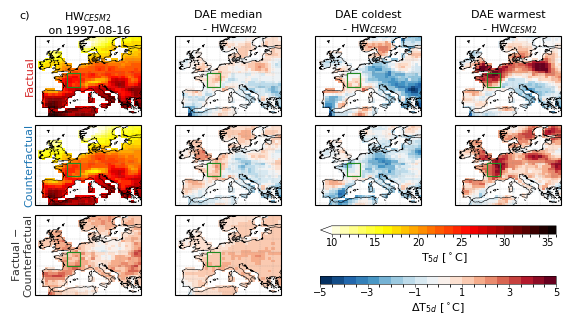

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

# ---------------------------------------------------------------------
# Publication figure settings
# ---------------------------------------------------------------------
FIG_WIDTH_MM = 153
FIG_WIDTH_IN = FIG_WIDTH_MM / 25.4
FIG_HEIGHT_IN = FIG_WIDTH_IN * 0.5

FONT_SIZE = 8

plt.rcParams.update({
    "font.size": FONT_SIZE,
    "axes.labelsize": FONT_SIZE,
    "axes.titlesize": FONT_SIZE,
    "xtick.labelsize": FONT_SIZE,
    "ytick.labelsize": FONT_SIZE,
    "legend.fontsize": FONT_SIZE - 1,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ---------------------------------------------------------------------
# Select event
# ---------------------------------------------------------------------
date = 2808 #3000 #=year 2036
year = 1997
hw_month = "08"
hw_day = "16"

date_text = f"{year}-{hw_month}-{hw_day}"

print("Date:", ds_test_eth_fact.isel(time=date).time.values)

# ---------------------------------------------------------------------
# Compute ensemble means
# ---------------------------------------------------------------------
fact_dae_mean_h = dae_eth_fact.TREFHT
cf_dae_mean_h = dae_eth_cf.TREFHT

# ---------------------------------------------------------------------
# Find coldest / warmest members
# ---------------------------------------------------------------------
imin_fact = dae_eth_ens_spatial_mean.TREFHT.isel(time=date).argmin(dim="ensemble_member")
imax_fact = dae_eth_ens_spatial_mean.TREFHT.isel(time=date).argmax(dim="ensemble_member")
imin_cf = dae_eth_ens_spatial_mean_cf.TREFHT.isel(time=date).argmin(dim="ensemble_member")
imax_cf = dae_eth_ens_spatial_mean_cf.TREFHT.isel(time=date).argmax(dim="ensemble_member")
print("indices:", imin_fact, imax_fact, imin_cf, imax_cf)
# ---------------------------------------------------------------------
# Absolute fields — needed both for the diff-to-truth rows (1-2)
# and for the factual-minus-counterfactual row (3)
# ---------------------------------------------------------------------
fact_col0 = ds_test_eth_fact.isel(time=date)
cf_col0 = ds_test_eth_cf.isel(time=date)

fact_fields = [
    fact_col0,
    fact_dae_mean_h.isel(time=date).median(dim="ensemble_member"),
    dae_eth_fact.TREFHT.isel(ensemble_member=imin_fact, time=date),
    dae_eth_fact.TREFHT.isel(ensemble_member=imax_fact, time=date),
]

cf_fields = [
    cf_col0,
    cf_dae_mean_h.isel(time=date).median(dim="ensemble_member"),
    dae_eth_cf.TREFHT.isel(ensemble_member=imin_cf, time=date),
    dae_eth_cf.TREFHT.isel(ensemble_member=imax_cf, time=date),
]

# Row 1: factual — column 0 stays absolute, columns 1-3 become diffs to column 0
fact_diffs = [f - fact_col0.values for f in fact_fields[1:]]

# Row 2: counterfactual — same treatment
cf_diffs = [f - cf_col0.values for f in cf_fields[1:]]

# Row 3: factual minus counterfactual, panel-by-panel (uses the absolute fields)
diff_fields = [f - c.values for f, c in zip(fact_fields, cf_fields)]

fields = [fact_col0, *fact_diffs, cf_col0, *cf_diffs, *diff_fields]
is_diff_col = [False, True, True, True,   # row 1
               False, True, True, True,   # row 2
               True, True, True, True]    # row 3 — all diff-scale

titles = [
    #f"CESM2: HW$_{{{date_text}}}$",
    f"HW$_{{CESM2}}$\n on {date_text}",
    f"DAE median\n - HW$_{{CESM2}}$",
    f"DAE coldest\n - HW$_{{CESM2}}$",
    f"DAE warmest\n - HW$_{{CESM2}}$",
    "", "", "", "",
    "", "", "", "",
]

# indices (in the flat 12-panel layout) to leave empty: row 3, cols 2 and 3
skip_indices = {10, 11}

# ---------------------------------------------------------------------
# Plot settings — absolute (rows 1-2, column 0)
# ---------------------------------------------------------------------
vmin = 10
vmax = 36
levels = np.linspace(vmin, vmax, 27)
cbar_ticks = np.arange(10, 37, 5)
cmap = "hot_r"

# Plot settings — differences (rows 1-2 cols 1-3, and all of row 3)
diff_vmin, diff_vmax = -5, 5
diff_levels = np.linspace(diff_vmin, diff_vmax, 21)
diff_cbar_ticks = np.arange(diff_vmin, diff_vmax + 1, 2)
diff_cmap = "RdBu_r"

# France domain box
box_lat_min, box_lat_max = 45, 50
box_lon_min, box_lon_max = 0, 5
box_lons = [box_lon_min, box_lon_max, box_lon_max, box_lon_min, box_lon_min]
box_lats = [box_lat_min, box_lat_min, box_lat_max, box_lat_max, box_lat_min]

# ---------------------------------------------------------------------
# Create figure with GridSpec: 4 equal panel columns x 3 rows
# ---------------------------------------------------------------------
fig = plt.figure(figsize=(FIG_WIDTH_IN, FIG_HEIGHT_IN))

gs = GridSpec(
    3, 4,
    wspace=0.15,
    hspace=0.12,
    left=0.08,
    right=0.98,
    bottom=0.07,
    top=0.93,
    figure=fig,
)

axes = []
for row in range(3):
    for col in range(4):
        ax = fig.add_subplot(gs[row, col], projection=ccrs.PlateCarree())
        axes.append(ax)

# ---------------------------------------------------------------------
# Plot panels
# ---------------------------------------------------------------------
pc_main = None
pc_diff = None

for i, (ax, field, title, diff_col) in enumerate(zip(axes, fields, titles, is_diff_col)):

    if i in skip_indices:
        ax.set_visible(False)  # leave this panel empty (colorbars go here instead)
        continue

    ax.add_feature(cfeature.LAND, facecolor="0.88", edgecolor="none", zorder=0)
    ax.coastlines(resolution="50m", linewidth=0.4, zorder=3)

    pc = field.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=diff_cmap if diff_col else cmap,
        levels=diff_levels if diff_col else levels,
        vmin=diff_vmin if diff_col else vmin,
        vmax=diff_vmax if diff_col else vmax,
        add_colorbar=False,
        rasterized=True,
        zorder=2,
    )

    if diff_col:
        pc_diff = pc
    else:
        pc_main = pc

    ax.plot(box_lons, box_lats, transform=ccrs.PlateCarree(),
            color="forestgreen", linewidth=0.8, zorder=4)

    ax.gridlines(draw_labels=False, linewidth=0.25, color="0.5",
                 alpha=0.5, linestyle="--", zorder=1)

    ax.set_title(title, pad=1, fontsize=8)

# ---------------------------------------------------------------------
# Row labels
# ---------------------------------------------------------------------
axes[0].text(-0.05, 0.5, "Factual", transform=axes[0].transAxes,
             rotation=90, va="center", ha="center", color="tab:red")

axes[4].text(-0.05, 0.5, "Counterfactual", transform=axes[4].transAxes,
             rotation=90, va="center", ha="center", color="tab:blue")

axes[8].text(-0.125, 0.5, "Factual $-$\nCounterfactual", transform=axes[8].transAxes,
             rotation=90, va="center", ha="center", color="0.2")

# ---------------------------------------------------------------------
# Panel label
# ---------------------------------------------------------------------
axes[0].text(-0.15, 1.2, "c)", transform=axes[0].transAxes, va="bottom", ha="left")

# ---------------------------------------------------------------------
# Colorbars — stacked vertically, spanning the combined width of both
# empty bottom-right panels (row 2, cols 2 AND 3 treated as one region)
# ---------------------------------------------------------------------

# bounding box of the *combined* two empty panel slots (cols 2-3, row 2)
pos_left = gs[2, 2].get_position(fig)
pos_right = gs[2, 3].get_position(fig)

combined_x0 = pos_left.x0
combined_x1 = pos_right.x1
combined_y0 = pos_left.y0
combined_y1 = pos_left.y1  # same row, same y-extent as pos_right

combined_w = combined_x1 - combined_x0
combined_h = combined_y1 - combined_y0

def stacked_hbar_rect(slot_index, n_slots=2, width_frac=0.9, height_frac=0.28, gap_frac=0.25):
    """Return [x0, y0, width, height] for a horizontal colorbar, one of
    `n_slots` stacked bars sharing the combined empty-panel region.
    slot_index=0 -> top bar, slot_index=1 -> bottom bar, etc.

    gap_frac controls the fraction of the combined height reserved as
    a gap between bars (independent of height_frac, which controls
    the bar's own thickness within its band).
    """
    w = combined_w * width_frac
    x0 = combined_x0 + (combined_w - w) / 2

    # reserve a gap in the middle, split remaining height into n_slots bands
    gap_h = combined_h * gap_frac
    usable_h = combined_h - gap_h * (n_slots - 1)
    band_h = usable_h / n_slots
    h = band_h * height_frac

    # stack top-to-bottom, inserting gap_h between consecutive bands
    band_y1 = combined_y0 + combined_h - slot_index * (band_h + gap_h)
    band_y0 = band_y1 - band_h
    y0 = band_y0 + (band_h - h) / 2

    return [x0, y0, w, h]

# top bar: main (absolute temperature) colorbar
cax_main = fig.add_axes(stacked_hbar_rect(slot_index=0))
cbar_main = fig.colorbar(
    pc_main, cax=cax_main, orientation="horizontal",
    boundaries=levels, ticks=cbar_ticks, spacing="proportional",
)
cbar_main.set_label(r"$\mathrm{T}_{5d}$ [$^\circ$C]", labelpad=2)
cbar_main.ax.tick_params(labelsize=FONT_SIZE - 1, width=0.4, length=2, pad=1)
cbar_main.outline.set_linewidth(0.4)

# bottom bar: difference colorbar
cax_diff = fig.add_axes(stacked_hbar_rect(slot_index=1))
cbar_diff = fig.colorbar(
    pc_diff, cax=cax_diff, orientation="horizontal",
    boundaries=diff_levels, ticks=diff_cbar_ticks, spacing="proportional",
)
cbar_diff.set_label(r"$\Delta \mathrm{T}_{5d}$ [$^\circ$C]", labelpad=2)
cbar_diff.ax.tick_params(labelsize=FONT_SIZE - 1, width=0.4, length=2, pad=1)
cbar_diff.outline.set_linewidth(0.4)

#fig.subplots_adjust(left=0.0, right=1.0, top=1.0, bottom=0.05, wspace=0.0, hspace=0.1)

# ---------------------------------------------------------------------
# Save
# ---------------------------------------------------------------------
#fig.savefig(f"Figure04c_updated.pdf", bbox_inches="tight")

plt.show()

## Time Series

<xarray.DataArray 'TREFHT' (time: 1729)> Size: 14kB
array([12.52316221, 16.69561772, 14.26134049, ..., 22.24754309,
       19.24404983, 21.35914987], shape=(1729,))
Coordinates:
  * time     (time) object 14kB 1950-06-02 00:00:00 ... 2040-08-31 00:00:00
DatetimeIndex(['1997-08-16'], dtype='datetime64[ns]', freq=None)


/tmp/ipykernel_2141940/457834473.py:319: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  time = ds_5day_jja_celsius.indexes["time"].to_datetimeindex()
/tmp/ipykernel_2141940/457834473.py:319: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  time = ds_5day_jja_celsius.indexes["time"].to_datetimeindex()
/tmp/ipykernel_2141940/457834473.py:320: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword ar

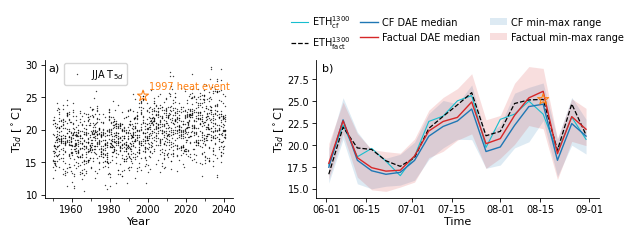

DatetimeIndex(['1997-08-16'], dtype='datetime64[ns]', freq=None)


In [8]:
# backup
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

date_text="1997-08-16"

# ---------------------------------------------------------------------
# Publication-ready settings
# ---------------------------------------------------------------------
FIG_WIDTH_MM = 153
FIG_WIDTH_IN = FIG_WIDTH_MM / 25.4
FIG_HEIGHT_IN = FIG_WIDTH_IN * 0.3

FONT_SIZE = 8
SMALL_FONT_SIZE = 7

plt.rcParams.update({
    "font.size": FONT_SIZE,
    "axes.labelsize": FONT_SIZE,
    "axes.titlesize": FONT_SIZE,
    "xtick.labelsize": SMALL_FONT_SIZE,
    "ytick.labelsize": SMALL_FONT_SIZE,
    "legend.fontsize": SMALL_FONT_SIZE,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.minor.width": 0.5,
    "ytick.minor.width": 0.5,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.minor.size": 1.8,
    "ytick.minor.size": 1.8,
})

# ---------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------
def weighted_domain_mean(da, lat_min, lat_max, lon_min, lon_max):
    """Latitude-weighted spatial mean over a rectangular domain."""
    da_domain = da.sel(
        lat=slice(lat_min, lat_max),
        lon=slice(lon_min, lon_max),
    )

    weights = np.cos(np.deg2rad(da_domain["lat"]))
    weights = xr.DataArray(
        weights,
        coords={"lat": da_domain["lat"]},
        dims=["lat"],
    )

    return da_domain.weighted(weights).mean(dim=("lat", "lon"))


def prepare_dpa_time_series(
    true_cf,
    dpa_ens_cf,
    dpa_ens_mean_cf,
    true_fact,
    dpa_ens_fact,
    dpa_ens_mean_fact,
    lat_min,
    lat_max,
    lon_min,
    lon_max,
    n_stds=2,
):
    if isinstance(dpa_ens_cf, xr.Dataset):
        dpa_ens_cf = dpa_ens_cf.TREFHT

    if isinstance(dpa_ens_fact, xr.Dataset):
        dpa_ens_fact = dpa_ens_fact.TREFHT

    true_cf_mean = weighted_domain_mean(
        true_cf, lat_min, lat_max, lon_min, lon_max
    )

    true_fact_mean = weighted_domain_mean(
        true_fact, lat_min, lat_max, lon_min, lon_max
    )

    dpa_cf_mean_pre = weighted_domain_mean(
        dpa_ens_cf, lat_min, lat_max, lon_min, lon_max
        #dpa_ens_mean_cf, lat_min, lat_max, lon_min, lon_max
    )

    dpa_fact_mean_pre = weighted_domain_mean(
        dpa_ens_fact, lat_min, lat_max, lon_min, lon_max
        #dpa_ens_mean_fact, lat_min, lat_max, lon_min, lon_max
    )
    
    # compute medians of DAE regional means ensemble 
    dpa_cf_mean = dpa_cf_mean_pre.median(dim="ensemble_member")
    dpa_fact_mean = dpa_fact_mean_pre.median(dim="ensemble_member")

    #dpa_cf_std = weighted_domain_mean(
    #    dpa_ens_cf.std(dim="ensemble_member"),
    #    lat_min,
    #    lat_max,
    #    lon_min,
    #    lon_max,
    #)

    #dpa_fact_std = weighted_domain_mean(
    #    dpa_ens_fact.std(dim="ensemble_member"),
    #    lat_min,
    #    lat_max,
    #    lon_min,
    #    lon_max,
    #)
    # min/max
    fact_lower = dpa_fact_mean_pre.min(dim="ensemble_member")
    fact_upper = dpa_fact_mean_pre.max(dim="ensemble_member")
    
    cf_lower = dpa_cf_mean_pre.min(dim="ensemble_member")
    cf_upper = dpa_cf_mean_pre.max(dim="ensemble_member")

    return {
        "true_cf": true_cf_mean,
        "true_fact": true_fact_mean,
        "dpa_cf_mean": dpa_cf_mean,
        "dpa_fact_mean": dpa_fact_mean,
        "cf_lower": cf_lower,
        "cf_upper": cf_upper,
        "fact_lower": fact_lower,
        "fact_upper": fact_upper,
        "n_stds": n_stds,
    }


def _to_datetime_index(da):
    return da.indexes["time"].to_datetimeindex()


def _select_year(da, plot_year):
    if plot_year is None:
        return da

    try:
        return da.sel(time=str(plot_year))
    except Exception:
        time = _to_datetime_index(da)
        return da.isel(time=time.year == int(plot_year))


def plot_dpa_time_series_on_ax(
    ax,
    ts,
    plot_year=None,
    panel_label="b)",
    ylabel=r"$\mathrm{T}_{5d}$ [$^\circ$C]",
):
    true_cf = _select_year(ts["true_cf"], plot_year)
    true_fact = _select_year(ts["true_fact"], plot_year)
    dpa_cf_mean = _select_year(ts["dpa_cf_mean"], plot_year)
    dpa_fact_mean = _select_year(ts["dpa_fact_mean"], plot_year)
    cf_lower = _select_year(ts["cf_lower"], plot_year)
    cf_upper = _select_year(ts["cf_upper"], plot_year)
    fact_lower = _select_year(ts["fact_lower"], plot_year)
    fact_upper = _select_year(ts["fact_upper"], plot_year)

    time = _to_datetime_index(true_fact)

    ax.plot(
        time,
        true_cf.values,
        color="tab:cyan",
        linewidth=0.8,
        linestyle="-",
        label=r"$\mathrm{ETH^{1300}_{cf}}$",
    )

    ax.plot(
        time,
        true_fact.values,
        color="black",
        linewidth=0.9,
        linestyle="--",
        label=r"$\mathrm{ETH^{1300}_{fact}}$",
    )
    

    ax.plot(
        time,
        dpa_cf_mean.values,
        color="tab:blue",
        linewidth=1.0,
        label="CF DAE median",
    )

    ax.plot(
        time,
        dpa_fact_mean.values,
        color="tab:red",
        linewidth=1.0,
        label="Factual DAE median",
    )

    ax.fill_between(
        time,
        cf_lower.values,
        cf_upper.values,
        color="tab:blue",
        alpha=0.15,
        linewidth=0,
        label="CF min-max range"
        #label=rf"CF DAE $\pm {ts['n_stds']}\sigma$",
    )

    ax.fill_between(
        time,
        fact_lower.values,
        fact_upper.values,
        color="tab:red",
        alpha=0.15,
        linewidth=0,
        label="Factual min-max range"
        #label=rf"Factual DAE $\pm {ts['n_stds']}\sigma$",
    )

    

    time_2003 = true_fact.sel(time=date_text).indexes["time"].to_datetimeindex()
    heatwave_value = true_fact.sel(time=date_text).values

    ax.scatter(
    time_2003,
    heatwave_value,
    marker="*",
    s=70,
    facecolors="none",
    edgecolors="tab:orange",
    linewidth=0.75,
    zorder=5,
    )
    
    ax.set_ylabel(ylabel, labelpad=1)
    ax.set_xlabel("Time", labelpad=1)

    #ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    #ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

    # ---------------------------------------------------------------------
    # Date formatting
    # ---------------------------------------------------------------------
    #ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
    
    #ax.xaxis.set_minor_locator(mdates.DayLocator(interval=3))

    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        pad=2,
    )
    ax.tick_params(
    axis="x",
    which="major",
    #rotation=45,
    )

    ax.text(
        0.02,
        0.98,
        panel_label,
        transform=ax.transAxes,
        fontsize=FONT_SIZE,
        #fontweight="bold",
        ha="left",
        va="top",
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        loc="lower center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=3,
        frameon=False,
        handlelength=1.8,
        columnspacing=1.0,
        handletextpad=0.4,
        borderaxespad=0.2,
    )


# ---------------------------------------------------------------------
# GER domain
# ---------------------------------------------------------------------


# France domain box
box_lat_min = fr_lat_min #45
box_lat_max = fr_lat_max #50
box_lon_min = fr_lon_min #0
box_lon_max = fr_lon_max #5

# ---------------------------------------------------------------------
# Left-panel data: absolute time series
# ---------------------------------------------------------------------
ds_1300 = ds_test_eth_fact.isel(time=slice(0,4769)).sel(time=slice("1950-06-02","2040-08-31")) #subset to 1300 test member

trefht_1300_abs = ut.get_ger_1d_data(
    ds_1300,
    lat_min=fr_lat_min,
    lat_max=fr_lat_max,
    lon_min=fr_lon_min,
    lon_max=fr_lon_max,
)

ds_5day_jja_celsius = trefht_1300_abs
print(ds_5day_jja_celsius)
time = ds_5day_jja_celsius.indexes["time"].to_datetimeindex()
time_2003 = ds_5day_jja_celsius.sel(time=str(date_text)).indexes["time"].to_datetimeindex()
heatwave_value = ds_5day_jja_celsius.sel(time=date_text).values

print(time_2003)

# ---------------------------------------------------------------------
# Right-panel data: DAE time series
# ---------------------------------------------------------------------
year_tp = year

ts = prepare_dpa_time_series(
    true_cf=ds_test_eth_cf.isel(time=slice(0, 4769)),
    dpa_ens_cf=dae_eth_cf.isel(time=slice(0, 4769)),
    dpa_ens_mean_cf=cf_dae_mean, #dae_eth_cf.isel(time=slice(0, 4769)).median(dim="ensemble_member"),

    true_fact=ds_test_eth_fact.isel(time=slice(0, 4769)),
    dpa_ens_fact=dae_eth_fact.isel(time=slice(0, 4769)),
    dpa_ens_mean_fact=fact_dae_mean, #ae_eth_fact.isel(time=slice(0, 4769)).median(dim="ensemble_member"),

    lat_min=fr_lat_min,
    lat_max=fr_lat_max,
    lon_min=fr_lon_min,
    lon_max=fr_lon_max,
    n_stds=2,
)

# ---------------------------------------------------------------------
# Combined figure: 153 mm total width, 1/1 width ratio
# ---------------------------------------------------------------------
fig = plt.figure(figsize=(FIG_WIDTH_IN, FIG_HEIGHT_IN))

gs = fig.add_gridspec(
    nrows=1,
    ncols=2,
    width_ratios=[0.4, 0.6],
    wspace=0.35,
)

ax_left = fig.add_subplot(gs[0, 0])
ax_right = fig.add_subplot(gs[0, 1])

# =====================================================================
# LEFT PANEL: long-term absolute time series
# =====================================================================
ax_left.scatter(
    time,
    ds_5day_jja_celsius.values,
    marker=".",
    s=4,
    color="black",
    alpha=0.75,
    linewidths=0,
    label=r"JJA $\mathrm{T}_{5d}$",
)

ax_left.scatter(
    time_2003,
    heatwave_value,
    marker="*",
    s=70,
    facecolors="none",
    edgecolors="tab:orange",
    linewidth=0.75,
    zorder=5,
)

ax_left.annotate(
    "1997 heat event",
    xy=(time_2003[0], heatwave_value),
    xytext=(4, 3),
    textcoords="offset points",
    fontsize=SMALL_FONT_SIZE,
    color="tab:orange",
    ha="left",
    va="bottom",
)

ax_left.set_ylabel(r"$\mathrm{T}_{5d}$ [$^\circ$C]", labelpad=1)
ax_left.set_xlabel("Year", labelpad=1)

ax_left.xaxis.set_major_locator(mdates.YearLocator(base=20))
ax_left.xaxis.set_minor_locator(mdates.YearLocator(base=10))
ax_left.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax_left.tick_params(
    axis="both",
    which="major",
    direction="out",
    pad=2,
)

ax_left.tick_params(
    axis="x",
    which="minor",
    direction="out",
)

ax_left.spines["top"].set_visible(False)
ax_left.spines["right"].set_visible(False)

ax_left.legend(
    loc="upper left",
    bbox_to_anchor=(0.10, 0.98),
    frameon=True,
    handletextpad=0.4,
    borderaxespad=0.0,
    labelspacing=0.35,
    fontsize=SMALL_FONT_SIZE,
)

ax_left.text(
    0.02,
    0.98,
    "a)",
    transform=ax_left.transAxes,
    fontsize=FONT_SIZE,
    #fontweight="bold",
    ha="left",
    va="top",
)

# =====================================================================
# RIGHT PANEL: DAE event time series
# =====================================================================
plot_dpa_time_series_on_ax(
    ax_right,
    ts,
    plot_year=year_tp,
    panel_label="b)",
    ylabel=r"$\mathrm{T}_{5d}$ [$^\circ$C]",
)

# ---------------------------------------------------------------------
# Final layout
# ---------------------------------------------------------------------
fig.subplots_adjust(
    left=0.065,
    right=0.985,
    bottom=0.20,
    top=0.96,
)

# ---------------------------------------------------------------------
# Save
# ---------------------------------------------------------------------
#fig.savefig(f"/home/sc.uni-leipzig.de/fl53wumy/llaae_new/TowardsDistributionalAutoencoderClimateCounterfactuals/figures/model_6037/combined_time_series_{year_tp}.pdf",bbox_inches="tight",pad_inches=0.01)

plt.show()

ts
print(time_2003)

In [9]:
# Factual
ds_test_le_fact = ds_test_eth_fact 
# unstack time --> ensemble members

# ds dims: time=476900, lat=32, lon=32
n_ens = 3
n_t = 4769

if ds_test_le_fact.sizes["time"] != n_ens * n_t:
    raise ValueError("time dimension does not match 3 * 4769")

# build ensemble and within-member time-step labels
ens = np.repeat(np.arange(1, n_ens + 1), n_t)
t_in_ens = np.tile(np.arange(n_t), n_ens)

# replace the 1D time index by a MultiIndex, then unstack
ds_test_le_fact_unstacked = (
    ds_test_le_fact.assign_coords(
        time=pd.MultiIndex.from_arrays(
            [ens, t_in_ens],
            names=["member", "time_in_member"]
        )
    )
    .unstack("time")
    .assign_coords(time_in_member=ds_test_le_fact.isel(time=slice(0,4769)).time.values)
)


# factual distribution (1972-2022)
trefht_le_fact_2011_61 = ds_test_le_fact_unstacked.sel(time_in_member=slice("1972", "2022"))

trefht_le_fact_0627 = trefht_le_fact_2011_61.sel(
    time_in_member=(trefht_le_fact_2011_61.time_in_member.dt.month == 8) & (trefht_le_fact_2011_61.time_in_member.dt.day == 16)
)
trefht_le_fact_0627

# counterfactual distribution (1850-1900)
trefht_le_fact_1850_1900 = ds_test_le_fact_unstacked.sel(time_in_member=slice("1850", "1900"))

trefht_le_cf_0627 = trefht_le_fact_1850_1900.sel(
    time_in_member=(trefht_le_fact_1850_1900.time_in_member.dt.month == 8) & (trefht_le_fact_1850_1900.time_in_member.dt.day == 16)
)
trefht_le_fact_0627

trefht_le_fact_0627_ger = ut.get_ger_1d_data(trefht_le_fact_0627, 
                                     lat_min = fr_lat_min,
                                     lat_max = fr_lat_max,
                                     lon_min = fr_lon_min,
                                     lon_max = fr_lon_max
                                            )
trefht_le_cf_0627_ger = ut.get_ger_1d_data(trefht_le_cf_0627,
                                     lat_min = fr_lat_min,
                                     lat_max = fr_lat_max,
                                     lon_min = fr_lon_min,
                                     lon_max = fr_lon_max
                                          )

/tmp/ipykernel_2141940/3963993169.py:18: FutureWarning: the `pandas.MultiIndex` object(s) passed as 'time' coordinate(s) or data variable(s) will no longer be implicitly promoted and wrapped into multiple indexed coordinates in the future (i.e., one coordinate for each multi-index level + one dimension coordinate). If you want to keep this behavior, you need to first wrap it explicitly using `mindex_coords = xarray.Coordinates.from_pandas_multiindex(mindex_obj, 'dim')` and pass it as coordinates, e.g., `xarray.Dataset(coords=mindex_coords)`, `dataset.assign_coords(mindex_coords)` or `dataarray.assign_coords(mindex_coords)`.
  ds_test_le_fact.assign_coords(


In [10]:
# define functions
from matplotlib.patches import Patch

#importlib.reload(evaluation)

# ---------------------------------------------------------------------
# Region settings
# ---------------------------------------------------------------------
LAT_MIN, LAT_MAX = fr_lat_min, fr_lat_max
LON_MIN, LON_MAX = fr_lon_min, fr_lon_max

TIME_SLICE = slice(0, 4769)
YEAR = year #1506
DATE = date_text #"2019-06-27"

N_BOOT = 2000
ALPHA = 0.05
TEXT_FS = 8#text_fs  # assumes text_fs already exists in your notebook/script

# ---------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------
def area_weighted_mean(data, lat_min, lat_max, lon_min, lon_max, time=None):
    """Compute cosine-latitude weighted regional mean."""
    regional = data.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))
    if time is not None:
        regional = regional.sel(time=time)

    weights = np.cos(np.deg2rad(regional["lat"]))
    weights_da = xr.DataArray(weights, coords={"lat": regional["lat"]}, dims=["lat"])

    return regional.weighted(weights_da).mean(dim=("lat", "lon"))


def bootstrap_median(values, n_boot=1000, alpha=0.05, rng=None):
    """
    Bootstrap the sample median and return:
    - median of bootstrap medians
    - lower / upper CI of bootstrap medians
    - all bootstrap medians
    """
    values = np.asarray(values).ravel()
    n = values.size

    if rng is None:
        rng = np.random.default_rng()

    boot_medians = np.empty(n_boot, dtype=float)

    for i in range(n_boot):
        sample = rng.choice(values, size=n, replace=True)
        boot_medians[i] = np.median(sample)

    lower_q = 100 * (alpha / 2)
    upper_q = 100 * (1 - alpha / 2)

    median_of_medians = np.median(boot_medians)
    ci_low = np.percentile(boot_medians, lower_q)
    ci_high = np.percentile(boot_medians, upper_q)

    return median_of_medians, ci_low, ci_high, boot_medians


def bootstrap_kde_ci(samples, x_grid, n_boot=1000, alpha=0.05, rng=None, bw_method=None):
    """
    Bootstrap pointwise confidence intervals for a Gaussian KDE.

    Returns
    -------
    kde_ref : ndarray
        KDE estimated from the original sample.
    kde_low : ndarray
        Lower pointwise confidence bound.
    kde_high : ndarray
        Upper pointwise confidence bound.
    kde_boot : ndarray
        All bootstrap KDE evaluations.
    """
    samples = np.asarray(samples).ravel()
    n = samples.size

    if rng is None:
        rng = np.random.default_rng()

    kde_boot = np.empty((n_boot, len(x_grid)), dtype=float)

    for i in range(n_boot):
        resample = rng.choice(samples, size=n, replace=True)
        kde = gaussian_kde(resample, bw_method=bw_method)
        kde_boot[i] = kde(x_grid)

    kde_ref = gaussian_kde(samples, bw_method=bw_method)(x_grid)

    lower_q = 100 * (alpha / 2)
    upper_q = 100 * (1 - alpha / 2)

    kde_low = np.percentile(kde_boot, lower_q, axis=0)
    kde_high = np.percentile(kde_boot, upper_q, axis=0)

    return kde_ref, kde_low, kde_high, kde_boot


# ---------------------------------------------------------------------
# Load data
# ---------------------------------------------------------------------
cf_truth_all = ds_test_eth_cf.isel(time=TIME_SLICE)
cf_ensemble_all = dae_eth_cf.isel(time=TIME_SLICE).TREFHT
cf_ensemble_mean_all = cf_dae_mean.isel(time=TIME_SLICE)

fact_truth_all = ds_test_eth_fact.isel(time=TIME_SLICE)
fact_ensemble_all = dae_eth_fact.isel(time=TIME_SLICE)
fact_ensemble_mean_all = fact_dae_mean.isel(time=TIME_SLICE)



# ---------------------------------------------------------------------
# Regional averages on selected date
# ---------------------------------------------------------------------
# Counterfactual
cf_single_ensemble_mean_ger = area_weighted_mean(
    cf_ensemble_mean_all, LAT_MIN, LAT_MAX, LON_MIN, LON_MAX, time=DATE
)
cf_ensemble_members_ger = area_weighted_mean(
    cf_ensemble_all, LAT_MIN, LAT_MAX, LON_MIN, LON_MAX, time=DATE
)
cf_truth_ger = area_weighted_mean(
    cf_truth_all, LAT_MIN, LAT_MAX, LON_MIN, LON_MAX, time=DATE
)

# Factual
fact_single_ensemble_mean_ger = area_weighted_mean(
    fact_ensemble_mean_all, LAT_MIN, LAT_MAX, LON_MIN, LON_MAX, time=DATE
)
fact_ensemble_members_ger = area_weighted_mean(
    fact_ensemble_all.TREFHT, LAT_MIN, LAT_MAX, LON_MIN, LON_MAX, time=DATE
)
fact_truth_ger = area_weighted_mean(
    fact_truth_all, LAT_MIN, LAT_MAX, LON_MIN, LON_MAX, time=DATE
)

cf_values = cf_ensemble_members_ger.values.ravel()
fact_values = fact_ensemble_members_ger.values.ravel()

# ---------------------------------------------------------------------
# Bootstrap medians
# ---------------------------------------------------------------------
cf_boot_median, cf_median_ci_low, cf_median_ci_high, cf_boot_medians = bootstrap_median(
    cf_values,
    n_boot=N_BOOT,
    alpha=ALPHA,
    rng=np.random.default_rng(42),
)

fact_boot_median, fact_median_ci_low, fact_median_ci_high, fact_boot_medians = bootstrap_median(
    fact_values,
    n_boot=N_BOOT,
    alpha=ALPHA,
    rng=np.random.default_rng(43),
)

# ---------------------------------------------------------------------
# KDE + bootstrap KDE confidence intervals
# ---------------------------------------------------------------------
bins = np.linspace(
    min(cf_values.min(), fact_values.min()),
    max(cf_values.max(), fact_values.max()),
    30,
)
x = np.linspace(bins[0], bins[-1], 500)

# Optional fixed bandwidth for more stable bootstrap-KDE CIs
cf_bw = gaussian_kde(cf_values).factor
fact_bw = gaussian_kde(fact_values).factor

cf_kde, cf_kde_low, cf_kde_high, _ = bootstrap_kde_ci(
    cf_values,
    x_grid=x,
    n_boot=N_BOOT,
    alpha=ALPHA,
    rng=np.random.default_rng(44),
    bw_method=cf_bw,
)

fact_kde, fact_kde_low, fact_kde_high, _ = bootstrap_kde_ci(
    fact_values,
    x_grid=x,
    n_boot=N_BOOT,
    alpha=ALPHA,
    rng=np.random.default_rng(45),
    bw_method=fact_bw,
)



from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase

class HandlerTwoColorPatch(HandlerBase):
    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize, trans):

        r1 = Rectangle(
            (xdescent, ydescent), width/2, height,
            facecolor="tab:blue", alpha=0.15, transform=trans
        )
        r2 = Rectangle(
            (xdescent + width/2, ydescent), width/2, height,
            facecolor="tab:red", alpha=0.15, transform=trans
        )

        return [r1, r2]

# ci_handle = object()


In [11]:
# ---------------------------------------------------------------------
# Bootstrap probability ratios for P(T >= observed)
# and plot as a box plot
# ---------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt


def bootstrap_probability_ratio(
    fact_values,
    cf_values,
    threshold,
    n_boot=2000,
    rng=None,
    correction=0.0,
):
    """
    Bootstrap the probability ratio

        PR = P_fact(T >= threshold) / P_cf(T >= threshold)

    using ensemble-member resampling with replacement.

    Parameters
    ----------
    fact_values : array-like
        Factual ensemble values for one day / region.
    cf_values : array-like
        Counterfactual ensemble values for one day / region.
    threshold : float
        Observed threshold temperature.
    n_boot : int
        Number of bootstrap resamples.
    rng : np.random.Generator or None
        Random number generator.
    correction : float
        Continuity correction to avoid division by zero when the
        counterfactual exceedance count is 0. Applied to both numerator
        and denominator counts as:
            p = (k + correction) / (n + 2 * correction)

    Returns
    -------
    pr_boot : ndarray
        Bootstrapped probability ratios.
    p_fact_boot : ndarray
        Bootstrapped factual exceedance probabilities.
    p_cf_boot : ndarray
        Bootstrapped counterfactual exceedance probabilities.
    """
    fact_values = np.asarray(fact_values).ravel()
    cf_values = np.asarray(cf_values).ravel()

    n_fact = fact_values.size
    n_cf = cf_values.size

    if rng is None:
        rng = np.random.default_rng()

    pr_boot = np.empty(n_boot, dtype=float)
    p_fact_boot = np.empty(n_boot, dtype=float)
    p_cf_boot = np.empty(n_boot, dtype=float)

    for i in range(n_boot):
        fact_sample = rng.choice(fact_values, size=n_fact, replace=True)
        cf_sample = rng.choice(cf_values, size=n_cf, replace=True)

        k_fact = np.sum(fact_sample >= threshold)
        k_cf = np.sum(cf_sample >= threshold)
        #print("k_cf:", k_cf)

        # Continuity-corrected exceedance probabilities
        p_fact = (k_fact + correction) / (n_fact + 2 * correction)
        p_cf = (k_cf + correction) / (n_cf + 2 * correction)

        p_fact_boot[i] = p_fact
        p_cf_boot[i] = p_cf
        #pr_boot[i] = p_fact / p_cf

        if p_cf != 0:
            pr_boot[i] = p_fact / p_cf
        else:
            pr_boot[i] = 10e8

    return pr_boot, p_fact_boot, p_cf_boot


# ---------------------------------------------------------------------
# Use existing values from your earlier code
# ---------------------------------------------------------------------
# Assumes these already exist:
#   fact_values
#   cf_values
#   fact_truth_ger
#   TEXT_FS

boot_median_diff = fact_boot_medians - cf_boot_medians
print("Median intensity change:", np.percentile(boot_median_diff, 50))


t_obs = float(fact_truth_ger.values)

pr_boot, p_fact_boot, p_cf_boot = bootstrap_probability_ratio(
    fact_values=fact_values,
    cf_values=cf_values,
    threshold=t_obs,
    n_boot=2000,
    rng=np.random.default_rng(123),
    correction=0.5,
)

# Summary stats
pr_median = np.median(pr_boot)
pr_q025 = np.percentile(pr_boot, 2.5)
pr_q25 = np.percentile(pr_boot, 25)
pr_q75 = np.percentile(pr_boot, 75)
pr_q975 = np.percentile(pr_boot, 97.5)

print(f"Observed threshold: {t_obs:.3f} °C")
print(f"Median PR: {pr_median:.3f}")
print(f"IQR: [{pr_q25:.3f}, {pr_q75:.3f}]")
print(f"95% CI: [{pr_q025:.3f}, {pr_q975:.3f}]")



def bootstrap_intensity_shift(fact_values, cf_values, t_obs, n_boot=2000, rng=None):

    fact_values = np.asarray(fact_values)
    cf_values = np.asarray(cf_values)

    n_fact = len(fact_values)
    n_cf = len(cf_values)

    if rng is None:
        rng = np.random.default_rng()

    delta = np.empty(n_boot)

    for i in range(n_boot):

        fact_sample = rng.choice(fact_values, size=n_fact, replace=True)
        cf_sample = rng.choice(cf_values, size=n_cf, replace=True)

        p_fact = np.mean(fact_sample >= t_obs)
        t_cf_equiv = np.quantile(cf_sample, 1 - p_fact)

        delta[i] = t_obs - t_cf_equiv

    return delta


delta_boot = bootstrap_intensity_shift(
    fact_values,
    cf_values,
    t_obs,
    n_boot=2000,
    rng=np.random.default_rng(0)
)



Median intensity change: 1.4458037873213954
Observed threshold: 25.200 °C
Median PR: 2.508
IQR: [2.280, 2.803]
95% CI: [1.918, 3.531]


/tmp/ipykernel_2141940/2392374010.py:101: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  t_obs = float(fact_truth_ger.values)


Cond. stds: 1.045465051102601 0.9849307227187359
Factual cond. mean: 25.982769701999068
CF cond. mean: 24.735068377085558
cond. signal: 1.2477013249135105
Factual risk mean: 20.94144074061938
CF risk mean: 20.234317610827137
risk signal: 0.7071231297922438
SNR risk: 0.30765723732601663
SNR storyline: 1.222319096313342
Risk. stds: 2.2958341543311866 2.285932501745174


/tmp/ipykernel_2141940/2357088930.py:341: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  float(cf_truth_ger.values),
/tmp/ipykernel_2141940/2357088930.py:348: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  float(fact_truth_ger.values),


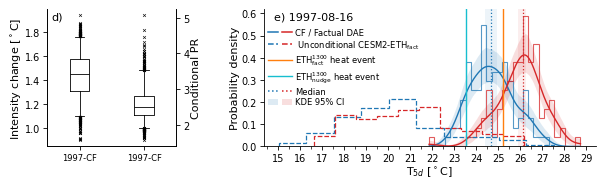

In [12]:
import importlib
importlib.reload(evaluation)
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator

# ---------------------------------------------------------------------
# Publication-ready settings
# ---------------------------------------------------------------------
FIG_WIDTH_MM = 153
FIG_WIDTH_IN = FIG_WIDTH_MM / 25.4

FIG_HEIGHT_IN = FIG_WIDTH_IN * 0.3 #0.42

FONT_SIZE = 8
SMALL_FONT_SIZE = 7
TINY_FONT_SIZE = 6

plt.rcParams.update({
    "font.size": FONT_SIZE,
    "axes.labelsize": FONT_SIZE,
    "axes.titlesize": FONT_SIZE,
    "xtick.labelsize": SMALL_FONT_SIZE,
    "ytick.labelsize": SMALL_FONT_SIZE,
    "legend.fontsize": TINY_FONT_SIZE,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.minor.width": 0.5,
    "ytick.minor.width": 0.5,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.minor.size": 1.8,
    "ytick.minor.size": 1.8,
})

# ---------------------------------------------------------------------
# Figure layout
# ---------------------------------------------------------------------
fig = plt.figure(figsize=(FIG_WIDTH_IN, FIG_HEIGHT_IN))

gs = fig.add_gridspec(
    nrows=1,
    ncols=2,
    width_ratios=[0.28, 0.72],
    wspace=0.38,
)

# =====================================================================
# LEFT PANEL: BOXPLOTS
# =====================================================================
ax1 = fig.add_subplot(gs[0, 0])

LW = 0.6

common_boxprops = {
    "widths": 0.30,
    "vert": True,
    "showfliers": True,
    "patch_artist": False,
    "flierprops": {
        "marker": "x",
        "markersize": 2,
        "markeredgewidth": 0.5,
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "alpha": 0.9,
    },
    "medianprops": {"linewidth": LW, "color": "black"},
    "boxprops": {"linewidth": LW, "color": "black"},
    "whiskerprops": {"linewidth": LW, "color": "black"},
    "capprops": {"linewidth": LW, "color": "black"},
}

# ---------------------------------------------------------------------
# Left axis: intensity change
# ---------------------------------------------------------------------
ax1.boxplot(
    boot_median_diff,
    positions=[1],
    whis=[2.5, 97.5],
    **common_boxprops,
)

#ax1.axhline(
#    0,
#    color="0.5",
#    linestyle="--",
#    linewidth=0.7,
#    zorder=0,
#)

ax1.set_ylabel(
    r"Intensity change [$^\circ$C]",
    labelpad=0.7,
)

ax1.set_xlim(0.5, 2.5)

ax1.tick_params(
    axis="both",
    which="major",
    direction="out",
    pad=2,
)

# ---------------------------------------------------------------------
# Right y-axis: conditional probability ratio
# ---------------------------------------------------------------------
ax2 = ax1.twinx()

ax2.boxplot(
    pr_boot,
    positions=[2],
    whis=[2.5, 97.5],
    **common_boxprops,
)

#ax2.axhline(
#    1,
#    color="0.5",
#    linestyle="--",
#    linewidth=0.7,
#    zorder=0,
#)

ax2.set_ylabel(
    "Conditional PR",
    labelpad=0.7,
)

#ax2.set_ylim(0, 30)

ax2.tick_params(
    axis="y",
    which="major",
    direction="out",
    pad=2,
)

# ---------------------------------------------------------------------
# X-axis formatting
# ---------------------------------------------------------------------
ax1.set_xticks([1, 2])

ax1.set_xticklabels(
    [
        "1997-CF",
        "1997-CF",
    ],
    fontsize=TINY_FONT_SIZE,
)

# ---------------------------------------------------------------------
# Panel label
# ---------------------------------------------------------------------
ax1.text(
    0.03,
    0.98,
    "d)",
    transform=ax1.transAxes,
    fontsize=FONT_SIZE,
    #fontweight="bold",
    ha="left",
    va="top",
)

# ---------------------------------------------------------------------
# Styling
# ---------------------------------------------------------------------
ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)

# =====================================================================
# RIGHT PANEL: DISTRIBUTIONS
# =====================================================================
ax = fig.add_subplot(gs[0, 1])

# ---------------------------------------------------------------------
# Conditional histograms
# ---------------------------------------------------------------------
ax.hist(
    cf_values,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=0.8,
    alpha=0.75,
    color="tab:blue",
)

ax.hist(
    fact_values,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=0.8,
    alpha=0.75,
    color="tab:red",
)



std_cond_fact = np.std(fact_values)
std_cond_cf = np.std(cf_values)
print("Cond. stds:", std_cond_fact, std_cond_cf)

print("Factual cond. mean:", np.mean(fact_values))
print("CF cond. mean:", np.mean(cf_values))
print("cond. signal:", np.mean(fact_values) - np.mean(cf_values))
#print("Factual cond. min/max:", np.min(b_risk), np.max(b_risk))
#print("CF cond. min/max:", np.min(a_risk), np.max(a_risk))

# ---------------------------------------------------------------------
# Unconditional histograms
# ---------------------------------------------------------------------
a_risk = trefht_le_cf_0627_ger.values.flatten()
b_risk = trefht_le_fact_0627_ger.values.flatten()

print("Factual risk mean:", np.mean(b_risk))
print("CF risk mean:", np.mean(a_risk))
print("risk signal:", np.mean(b_risk) - np.mean(a_risk))
#print("Factual risk min/max:", np.min(b_risk), np.max(b_risk))
#print("CF risk min/max:", np.min(a_risk), np.max(a_risk))


# signal to noise
snr_risk = evaluation.snr(b_risk, a_risk)
print("SNR risk:", snr_risk)

snr_cond = evaluation.snr(fact_values, cf_values)
print("SNR storyline:", snr_cond)

ax.hist(
    a_risk,
    #bins=bins,
    density=True,
    histtype="step",
    linewidth=0.9,
    linestyle="--",
    color="tab:blue",
)

ax.hist(
    b_risk,
    #bins=bins,
    density=True,
    histtype="step",
    linewidth=0.9,
    linestyle="--",
    color="tab:red",
)

std_risk_fact = np.std(b_risk)
std_risk_cf = np.std(a_risk)
print("Risk. stds:", std_risk_fact, std_risk_cf)

# ---------------------------------------------------------------------
# KDE confidence intervals
# ---------------------------------------------------------------------
ax.fill_between(
    x,
    cf_kde_low,
    cf_kde_high,
    color="tab:blue",
    alpha=0.15,
    linewidth=0,
)

ax.fill_between(
    x,
    fact_kde_low,
    fact_kde_high,
    color="tab:red",
    alpha=0.15,
    linewidth=0,
)

# ---------------------------------------------------------------------
# KDE lines
# ---------------------------------------------------------------------
ax.plot(
    x,
    cf_kde,
    color="tab:blue",
    linewidth=1.0,
)

ax.plot(
    x,
    fact_kde,
    color="tab:red",
    linewidth=1.0,
)

# ---------------------------------------------------------------------
# Median lines
# ---------------------------------------------------------------------
ax.axvline(
    float(cf_boot_median),
    color="tab:blue",
    linestyle=":",
    linewidth=0.9,
)

ax.axvline(
    float(fact_boot_median),
    color="tab:red",
    linestyle=":",
    linewidth=0.9,
)

# ---------------------------------------------------------------------
# Median confidence intervals
# ---------------------------------------------------------------------
ax.axvspan(
    cf_median_ci_low,
    cf_median_ci_high,
    color="tab:blue",
    alpha=0.08,
    linewidth=0,
)

ax.axvspan(
    fact_median_ci_low,
    fact_median_ci_high,
    color="tab:red",
    alpha=0.08,
    linewidth=0,
)

# ---------------------------------------------------------------------
# Truth lines
# ---------------------------------------------------------------------
ax.axvline(
    float(cf_truth_ger.values),
    color="tab:cyan",
    linestyle="-",
    linewidth=1,
)

ax.axvline(
    float(fact_truth_ger.values),
    color="tab:orange",
    linestyle="-",
    linewidth=1,
)

# ---------------------------------------------------------------------
# Labels
# ---------------------------------------------------------------------
ax.set_xlabel(
    r"$\mathrm{T}_{5d}$ [$^\circ$C]",
    labelpad=0.5,
)

ax.set_ylabel(
    "Probability density",
    labelpad=1,
)

# ---------------------------------------------------------------------
# Ticks
# ---------------------------------------------------------------------
ax.xaxis.set_major_locator(MultipleLocator(1.0))
ax.xaxis.set_minor_locator(MultipleLocator(0.5))

ax.tick_params(
    axis="both",
    which="major",
    direction="out",
    pad=2,
)

ax.tick_params(
    axis="x",
    which="minor",
    direction="out",
)

# ---------------------------------------------------------------------
# Panel and date labels
# ---------------------------------------------------------------------
ax.text(
    0.03,
    0.98,
    f"e) {DATE}",
    transform=ax.transAxes,
    fontsize=FONT_SIZE,
    #fontweight="bold",
    ha="left",
    va="top",
)

#ax.text(
#    0.03,
#    0.88,
#    f"{DATE}",
#    transform=ax.transAxes,
#    fontsize=TINY_FONT_SIZE,
#    ha="left",
#    va="top",
#)

# ---------------------------------------------------------------------
# Styling
# ---------------------------------------------------------------------
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ---------------------------------------------------------------------
# Compact combined legend
# ---------------------------------------------------------------------
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.legend_handler import HandlerTuple

legend_handles = [
    (
        Line2D([0], [0], color="tab:blue", linewidth=1.1),
        Line2D([0], [0], color="tab:red", linewidth=1.1),
    ),
    (
        Line2D([0], [0], color="tab:blue", linewidth=1.1,linestyle="--"),
        Line2D([0], [0], color="tab:red", linewidth=1.1,linestyle="--"),
    ),
    Line2D(
        [0], [0],
        color="tab:orange",
        linestyle="-",
        linewidth=1,
        label=r"$\mathrm{ETH^{1300}_{fact}}$ on 1997-07-22"
    ),
    Line2D(
        [0], [0],
        color="tab:cyan",
        linestyle="-",
        linewidth=1,
        label=r"$\mathrm{ETH^{1300}_{nudge}}$ on 1997-07-22"
    ),
    (
        Line2D([0], [0], color="tab:blue", linewidth=1.1, linestyle=":"),
        Line2D([0], [0], color="tab:red", linewidth=1.1, linestyle=":"),
    ),
    (
        Patch(facecolor="tab:blue",alpha=0.15, edgecolor="none"),
        Patch(facecolor="tab:red", alpha=0.15, edgecolor="none"),
    ),
]

legend_labels = [
    "CF / Factual DAE",
    " Unconditional " + r"$\mathrm{CESM2\text{-}ETH_{fact}}$", 
    r"$\mathrm{ETH^{1300}_{fact}}$ heat event",
    r"$\mathrm{ETH^{1300}_{nudge}}$ heat event",
    "Median",
    "KDE 95% CI",
]

ax.legend(
    handles=legend_handles,
    labels=legend_labels,
    handler_map={tuple: HandlerTuple(ndivide=None)},
    loc="upper left",
    bbox_to_anchor=(0.0, 0.9),
    frameon=False,
    handlelength=2.8,
    handletextpad=0.35,
    borderaxespad=0.15,
    labelspacing=0.22,
    columnspacing=0.55,
    ncol=1,
    fontsize=TINY_FONT_SIZE,
)

# ---------------------------------------------------------------------
# Final layout
# ---------------------------------------------------------------------
fig.subplots_adjust(
    left=0.075,
    right=0.985,
    bottom=0.20,
    top=0.96,
)

# ---------------------------------------------------------------------
# Save
# ---------------------------------------------------------------------
#fig.savefig("combined_attribution_figure.pdf",bbox_inches="tight",pad_inches=0.01)

plt.show()

In [13]:
# ---------------------------------------------------------------------
# Print intensity change statistics
# ---------------------------------------------------------------------
print("\n=== Intensity Change ===")

print("CF:")
print("  Median =", np.median(boot_median_diff))
print("  Mean   =", np.mean(boot_median_diff))
print("  95% CI =", np.percentile(boot_median_diff, [2.5, 97.5]))



# ---------------------------------------------------------------------
# Print PR statistics
# ---------------------------------------------------------------------
print("\n=== Conditional Probability Ratio (PR) ===")

print("CF:")
print("  Median =", np.median(pr_boot))
print("  Mean   =", np.mean(pr_boot))
print("  95% CI =", np.percentile(pr_boot, [2.5, 97.5]))




=== Intensity Change ===
CF:
  Median = 1.4458037873213954
  Mean   = 1.44265759981317
  95% CI = [1.09605466 1.75989702]

=== Conditional Probability Ratio (PR) ===
CF:
  Median = 2.5076923076923077
  Mean   = 2.5696165861163145
  95% CI = [1.91754539 3.53061224]


In [14]:
date = 3659 #=year 2036
print("Date:", ds_test_eth_fact.TREFHT.isel(time=date).time.values)

AttributeError: 'DataArray' object has no attribute 'TREFHT'

In [ ]:
fact_dae_mean = dae_eth_fact.TREFHT.mean(dim="ensemble_member")
cf_dae_mean = dae_eth_cf.TREFHT.mean(dim="ensemble_member")

# Example dataset: ds.TREFHT should exist
date = 3539 #=year 2036
date_text = "2042-07-27"
print("Date:", ds_test_eth_fact.TREFHT.isel(time=date).time.values)

# Factual Fields
# find min and max values of domain average temperature
imin_fact = (
    dae_eth_ens_spatial_mean
    .isel(time=date)
    .argmin(dim="ensemble_member")
)
imax_fact = (
    dae_eth_ens_spatial_mean
    .isel(time=date)
    .argmax(dim="ensemble_member")
)

field_factual = ds_test_eth_fact.TREFHT.isel(time=date)
field_1 = fact_dae_mean.isel(time=date)
field_2 = dae_eth_fact.TREFHT.isel(ensemble_member = imin_fact, time=date)
field_3 = dae_eth_fact.TREFHT.isel(ensemble_member = imax_fact, time=date)

# Counterfactual Fields

# find min and max values of domain average temperature
imin_cf = (
    dae_eth_ens_spatial_mean_cf
    .isel(time=date)
    .argmin(dim="ensemble_member")
)
imax_cf = (
    dae_eth_ens_spatial_mean_cf
    .isel(time=date)
    .argmax(dim="ensemble_member")
)

field_cf = ds_test_eth_cf.TREFHT.isel(time=date)
field_1_cf = cf_dae_mean.isel(time=date)
field_2_cf = dae_eth_cf.TREFHT.isel(ensemble_member = imin_cf, time=date)
field_3_cf = dae_eth_cf.TREFHT.isel(ensemble_member = imax_cf, time=date)

# Plot parameters
vmin = -10
vmax = 10
no_levels=21
levels = np.linspace(vmin,vmax,no_levels)
cmap = "coolwarm"

text_fs = 8

# GER domain
ger_lat_min = 48
ger_lat_max = 54
ger_lon_min = 6
ger_lon_max = 15


# Create figure and subplots
fig, axes = plt.subplots(
    2, 4,
    subplot_kw={'projection': ccrs.PlateCarree()},
    figsize=(6.5,2.5)#(14, 6)
)


titles = [f"CESM2 on {date_text}", "DAE: ensemble mean", "DAE: coldest member", "DAE: warmest member", "", "", "", ""]
fields = [field_factual, field_1, field_2, field_3, field_cf, field_1_cf, field_2_cf, field_3_cf]
axes = axes.flatten()

for ax, field, title in zip(axes, fields, titles):
    pc = field.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        levels=levels,
        add_colorbar=False
    )
    

    if ax == axes[0]:
        lons = [ger_lon_min, ger_lon_max, ger_lon_max, ger_lon_min, ger_lon_min]
        lats = [ger_lat_min, ger_lat_min, ger_lat_max, ger_lat_max, ger_lat_min]
        ax.plot(
            lons, lats,
            transform=ccrs.PlateCarree(),
            color="navy",
            linewidth=1.5,
            linestyle="-"
        )
    ax.coastlines(resolution="50m", linewidth=1)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.5)
    gl = ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    ax.set_title(title, fontsize=text_fs, pad=3)


# tighten the grid (no whitespace)
fig.subplots_adjust(left=0.03, right=0.88, bottom=0.06, top=0.92,
                    wspace=0.0, hspace=0.0)

# create a dedicated axis for the colorbar: [left, bottom, width, height]
cax = fig.add_axes([0.90, 0.15, 0.015, 0.7])

cbar = fig.colorbar(pc, cax=cax, orientation="vertical")
cbar.set_label("Temperature [°C]", fontsize=text_fs)
cbar.set_ticks(levels)
cbar.ax.tick_params(labelsize=6)

# Set tick positions
cbar.set_ticks(np.linspace(-10,10,11))

axes[0].text(-0.125, 0.5, f'Factual', transform=axes[0].transAxes,
              fontsize=text_fs, rotation=90, color="tab:orange", verticalalignment='center', horizontalalignment='left', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
axes[4].text(-0.125, 0.5, f'Counterfactual(CF)', transform=axes[4].transAxes,
              fontsize=text_fs, rotation=90, color="tab:cyan", verticalalignment='center', horizontalalignment='left', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
axes[0].text(-0.135,1,"(a)", transform=axes[0].transAxes, fontsize=text_fs)

fig.subplots_adjust(wspace=0.0, hspace=0.0)
#plt.savefig(f"dpa_field_sample_{date_text}.pdf")
plt.show()
